<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

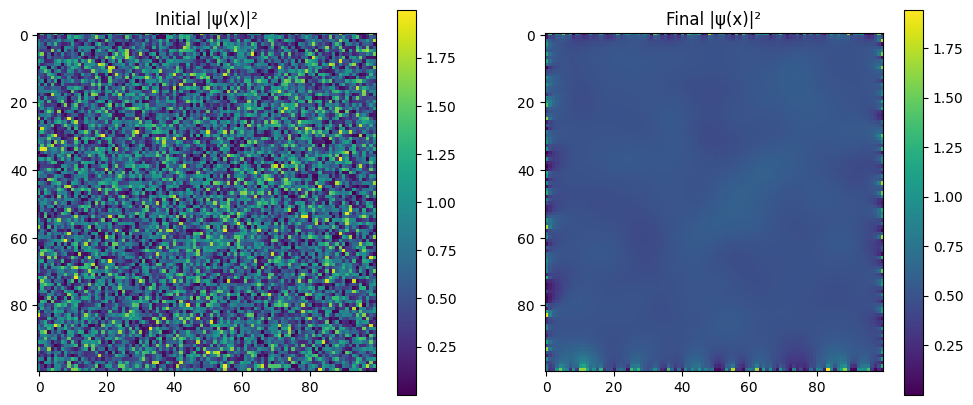

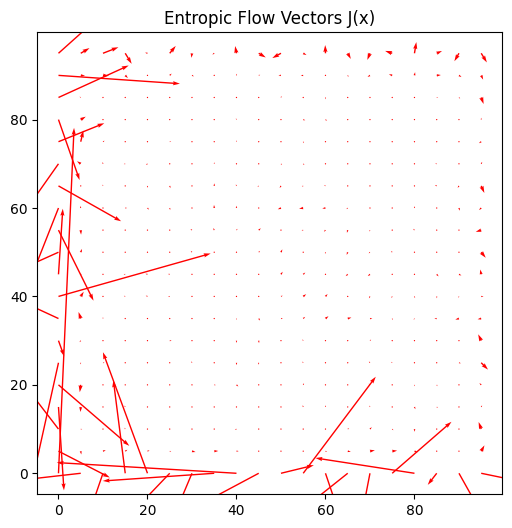

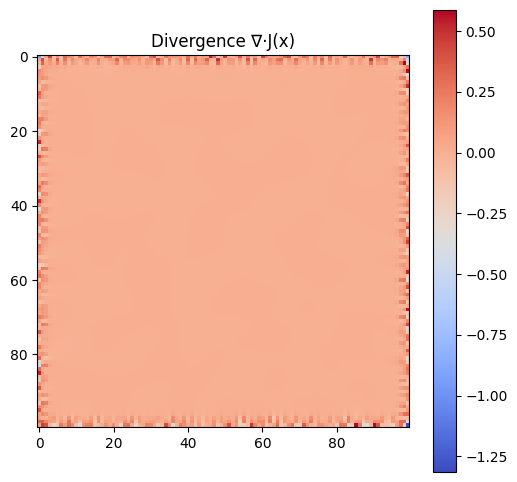

In [1]:
# Simulating QFT002: Conserved Current Scan in 2D HES lattice with nonlinear memory compensation

import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 100          # Lattice size
T = 50           # Time steps
epsilon = 0.1    # Compensation strength

# Initialize 2D lattice of complex attractor states ψ(x)
psi = np.random.rand(N, N) + 1j * np.random.rand(N, N)

# Store initial |ψ(x)|²
initial_magnitude = np.abs(psi)**2

# Evolution loop
for t in range(T):
    psi_new = np.copy(psi)
    for i in range(1, N-1):
        for j in range(1, N-1):
            # Neighbor influence (simple average)
            neighbor_sum = (psi[i+1,j] + psi[i-1,j] + psi[i,j+1] + psi[i,j-1]) / 4
            # Nonlinear memory compensation δA²(x)
            delta_A2 = np.abs(psi[i,j])**2 - np.abs(psi[i-1,j])**2
            compensation = epsilon * delta_A2
            # Update rule
            psi_new[i,j] = psi[i,j] + (neighbor_sum - psi[i,j]) + compensation
    psi = psi_new

# Final |ψ(x)|²
final_magnitude = np.abs(psi)**2

# Compute entropic flow vectors J(x) = ∇|ψ(x)|²
Jx, Jy = np.gradient(final_magnitude)

# Compute divergence ∇·J(x)
divergence = np.gradient(Jx, axis=0) + np.gradient(Jy, axis=1)

# Plot initial and final |ψ(x)|²
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(initial_magnitude, cmap='viridis')
plt.title('Initial |ψ(x)|²')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(final_magnitude, cmap='viridis')
plt.title('Final |ψ(x)|²')
plt.colorbar()
plt.show()

# Plot entropic flow vectors J(x)
plt.figure(figsize=(6, 6))
skip = 5
Y, X = np.mgrid[0:N:1, 0:N:1]
plt.quiver(X[::skip, ::skip], Y[::skip, ::skip], Jx[::skip, ::skip], Jy[::skip, ::skip], color='red')
plt.title('Entropic Flow Vectors J(x)')
plt.show()

# Plot divergence map ∇·J(x)
plt.figure(figsize=(6, 6))
plt.imshow(divergence, cmap='coolwarm')
plt.title('Divergence ∇·J(x)')
plt.colorbar()
plt.show()
